In [2]:
# Import libraries needed for database access, data processing, ML models and visualization

import mysql.connector
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [3]:
# Establish connection to the Moodle MySQL database

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Blah@5571",
    database="moodle"
)

print("Database connected:", connection.is_connected())

Database connected: True


In [4]:
# Retrieve and display available tables in the Moodle database

tables = pd.read_sql("SHOW TABLES", connection)

print("Total Tables:", len(tables))
tables.head(20)

Total Tables: 290


C:\Users\sanja\AppData\Local\Temp\ipykernel_1932\1038709011.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql("SHOW TABLES", connection)


,Tables_in_moodle
0,mdl_adminpresets
1,mdl_adminpresets_app
2,mdl_adminpresets_app_it
3,mdl_adminpresets_app_it_a
4,mdl_adminpresets_app_plug
5,mdl_adminpresets_it
6,mdl_adminpresets_it_a
7,mdl_adminpresets_plug
8,mdl_ai_action_generate_image
9,mdl_ai_action_generate_text


In [5]:
# Load user activity logs from Moodle
# This table contains records of user actions in the system

log_data = pd.read_sql(
    "SELECT * FROM mdl_logstore_standard_log",
    connection
)

print("Log dataset shape:", log_data.shape)
log_data.head()

C:\Users\sanja\AppData\Local\Temp\ipykernel_1932\1459317021.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  log_data = pd.read_sql(


Log dataset shape: (1389137, 21)


,id,eventname,component,action,target,objecttable,objectid,crud,edulevel,contextid,...,contextinstanceid,userid,courseid,relateduserid,anonymous,other,timecreated,origin,ip,realuserid
0,1,\core\event\user_loggedin,core,loggedin,user,user,2.0,r,0,1,...,0,2,0,NaN,0,"a:2:{s:8:""username"";s:5:""admin"";s:13:""extrause...",1738906152,web,172.17.8.11,NaN
1,2,\core\event\user_password_updated,core,updated,user_password,NaN,NaN,u,0,5,...,2,2,0,2.0,0,"a:1:{s:14:""forgottenreset"";b:0;}",1738906996,web,172.17.8.11,NaN
2,3,\core\event\user_updated,core,updated,user,user,2.0,u,0,5,...,2,2,0,2.0,0,N;,1738906996,web,172.17.8.11,NaN
3,4,\core\event\config_log_created,core,created,config_log,config_log,671.0,c,0,1,...,0,2,0,NaN,0,"a:4:{s:4:""name"";s:24:""enableaccessibilitytools...",1738906997,web,172.17.8.11,NaN
4,5,\core\event\config_log_created,core,created,config_log,config_log,672.0,c,0,1,...,0,2,0,NaN,0,"a:4:{s:4:""name"";s:15:""enablemoodlenet"";s:8:""ol...",1738906997,web,172.17.8.11,NaN


In [6]:
# Examine dataset columns and missing values to understand data quality

print("Columns in dataset:\n", log_data.columns)

print("\nMissing values per column:\n")
print(log_data.isnull().sum())

Columns in dataset:
 Index(['id', 'eventname', 'component', 'action', 'target', 'objecttable',
       'objectid', 'crud', 'edulevel', 'contextid', 'contextlevel',
       'contextinstanceid', 'userid', 'courseid', 'relateduserid', 'anonymous',
       'other', 'timecreated', 'origin', 'ip', 'realuserid'],
      dtype='str')

Missing values per column:

id                         0
eventname                  0
component                  0
action                     0
target                     0
objecttable           935954
objectid              935954
crud                       0
edulevel                   0
contextid                  0
contextlevel               0
contextinstanceid          0
userid                     0
courseid                   0
relateduserid        1025449
anonymous                  0
other                      0
timecreated                0
origin                     0
ip                     47645
realuserid           1389135
dtype: int64


In [7]:
# Drop columns that contain excessive missing values or irrelevant data

columns_to_drop = [
    "objecttable",
    "objectid",
    "relateduserid",
    "realuserid",
    "ip",
    "other"
]

log_data.drop(columns=columns_to_drop, inplace=True, errors="ignore")

print("Remaining columns:", log_data.columns)

Remaining columns: Index(['id', 'eventname', 'component', 'action', 'target', 'crud', 'edulevel',
       'contextid', 'contextlevel', 'contextinstanceid', 'userid', 'courseid',
       'anonymous', 'timecreated', 'origin'],
      dtype='str')


In [8]:
# Remove duplicate rows to improve data quality

log_data = log_data.drop_duplicates()

print("Dataset shape after removing duplicates:", log_data.shape)

Dataset shape after removing duplicates: (1389137, 15)


In [9]:
# Convert UNIX timestamp into datetime format
# Extract useful time-based features from the timestamp

log_data["timecreated"] = pd.to_datetime(
    log_data["timecreated"],
    unit="s"
)

log_data["year"] = log_data["timecreated"].dt.year
log_data["month"] = log_data["timecreated"].dt.month
log_data["day"] = log_data["timecreated"].dt.day
log_data["hour"] = log_data["timecreated"].dt.hour

# Drop original timestamp column since we created derived features
log_data.drop(columns=["timecreated"], inplace=True)

log_data.head()

,id,eventname,component,action,target,crud,edulevel,contextid,contextlevel,contextinstanceid,userid,courseid,anonymous,origin,year,month,day,hour
0,1,\core\event\user_loggedin,core,loggedin,user,r,0,1,10,0,2,0,0,web,2025,2,7,5
1,2,\core\event\user_password_updated,core,updated,user_password,u,0,5,30,2,2,0,0,web,2025,2,7,5
2,3,\core\event\user_updated,core,updated,user,u,0,5,30,2,2,0,0,web,2025,2,7,5
3,4,\core\event\config_log_created,core,created,config_log,c,0,1,10,0,2,0,0,web,2025,2,7,5
4,5,\core\event\config_log_created,core,created,config_log,c,0,1,10,0,2,0,0,web,2025,2,7,5


In [29]:
# Machine learning models require numeric input
# Convert categorical text columns into numeric form using Label Encoding

for col in log_data.select_dtypes(include=["object", "string"]).columns:

    encoder = LabelEncoder()
    log_data[col] = encoder.fit_transform(log_data[col].astype(str))

print("Encoding completed")

Encoding completed


In [11]:
# Load additional tables required for analysis
# Courses table contains course names and categories
# Grades table contains students' final grades
# Grade items table contains assessment names

courses = pd.read_sql(
    "SELECT id, fullname, category FROM mdl_course",
    connection
)

grades = pd.read_sql(
    "SELECT userid, itemid, finalgrade FROM mdl_grade_grades",
    connection
)

grade_items = pd.read_sql(
    "SELECT id, courseid, itemname FROM mdl_grade_items",
    connection
)

print("Tables loaded successfully")

C:\Users\sanja\AppData\Local\Temp\ipykernel_1932\1802293908.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  courses = pd.read_sql(
C:\Users\sanja\AppData\Local\Temp\ipykernel_1932\1802293908.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  grades = pd.read_sql(


Tables loaded successfully


C:\Users\sanja\AppData\Local\Temp\ipykernel_1932\1802293908.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  grade_items = pd.read_sql(


In [12]:
# The log dataset is very large (1.3M+ rows)
# Sampling is required before merging to avoid memory errors

log_sample = log_data.sample(
    n=150000,
    random_state=42
)

print("Sample dataset shape:", log_sample.shape)

Sample dataset shape: (150000, 18)


In [13]:
# Merge sampled log data with course information

log_course_data = log_sample.merge(
    courses,
    left_on="courseid",
    right_on="id",
    how="left"
)

print("After merging courses:", log_course_data.shape)

After merging courses: (150000, 21)


In [14]:
# Merge user grade information using userid

log_course_grade_data = log_course_data.merge(
    grades,
    on="userid",
    how="left"
)

print("After merging grades:", log_course_grade_data.shape)

After merging grades: (22556606, 23)


In [15]:
# Merge assessment or assignment names using itemid

final_data = log_course_grade_data.merge(
    grade_items,
    left_on="itemid",
    right_on="id",
    how="left"
)

print("After merging grade items:", final_data.shape)

After merging grade items: (22556606, 26)


In [16]:
# Reduce dataset again to ensure manageable size

final_data = final_data.sample(
    n=250000,
    random_state=42
)

print("Reduced dataset:", final_data.shape)

Reduced dataset: (250000, 26)


In [17]:
# Remove rows where final grade is missing
# These rows cannot be used for prediction

final_data = final_data.dropna(subset=["finalgrade"])

# Remove redundant columns created during merges
final_data.drop(
    columns=["id_x", "id_y", "id", "courseid_y"],
    inplace=True,
    errors="ignore"
)

# Fill missing values
final_data["fullname"] = final_data["fullname"].fillna("Unknown")
final_data["category"] = final_data["category"].fillna(0)

print("Cleaned dataset:", final_data.shape)

Cleaned dataset: (39183, 22)


In [18]:
# Encode remaining categorical columns

categorical_columns = [
    "eventname",
    "component",
    "action",
    "target",
    "crud",
    "origin",
    "fullname",
    "itemname"
]

for col in categorical_columns:
    
    encoder = LabelEncoder()
    final_data[col] = encoder.fit_transform(
        final_data[col].astype(str)
    )

print("Categorical encoding completed")

Categorical encoding completed


In [19]:
# Separate input features and target variable
# Target variable is the final grade

X = final_data.drop(columns=["finalgrade"])
y = final_data["finalgrade"]

print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Feature dataset shape: (39183, 21)
Target dataset shape: (39183,)


In [20]:
# Split dataset into training and testing sets
# 80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (31346, 21)
Testing data: (7837, 21)


In [21]:
# Train Random Forest Regressor model to predict final grades

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [22]:
# Predict grades for test dataset
# Evaluate model using MAE, MSE and R² metrics

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 6.677299226374889
MSE: 671.6052987416417
R² Score: 0.8168292001918342


In [23]:
# Random Forest provides feature importance scores
# These scores show how much each column contributes to prediction

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(10)

,feature,importance
19,itemid,0.529619
20,itemname,0.200931
9,userid,0.120610
16,hour,0.026614
15,day,0.026375
0,eventname,0.013623
2,action,0.012855
6,contextid,0.012436
10,courseid_x,0.011542
8,contextinstanceid,0.011345


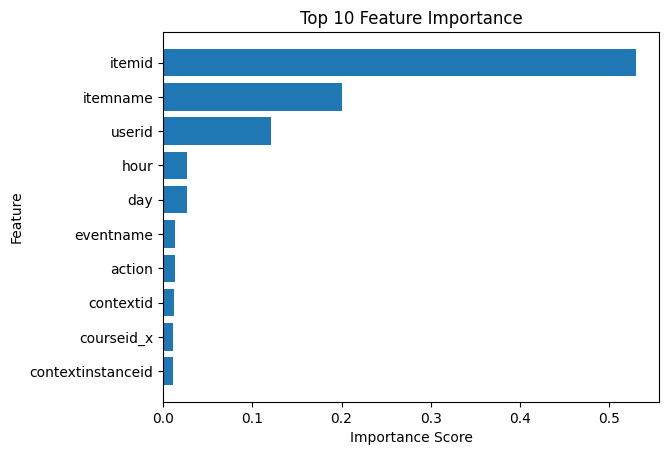

In [24]:
# Visualize the top 10 most important features

top_features = feature_importance.head(10)

plt.figure()

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [25]:
# Identify columns that have very low importance
# These columns can potentially be removed

low_importance_features = feature_importance[
    feature_importance["importance"] < 0.01
]

low_importance_features

,feature,importance
17,fullname,0.008841
1,component,0.003894
5,edulevel,0.002726
4,crud,0.002713
12,origin,0.002084
18,category,0.001785
7,contextlevel,0.001695
14,month,0.000060
11,anonymous,0.000000
13,year,0.000000


In [26]:
# Remove low importance columns and retrain the model
# This tests whether the model performance remains similar

columns_to_drop = low_importance_features["feature"].tolist()

X_reduced = X.drop(columns=columns_to_drop)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42
)

model_reduced = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_reduced.fit(X_train_r, y_train_r)

y_pred_r = model_reduced.predict(X_test_r)

r2_reduced = r2_score(y_test_r, y_pred_r)

print("Reduced Model R²:", r2_reduced)

Reduced Model R²: 0.8182444012082639


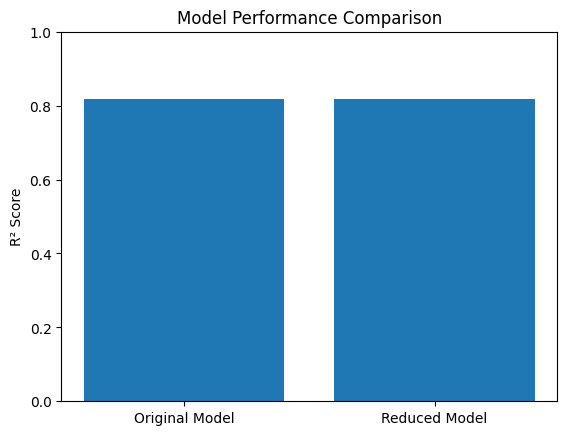

In [27]:
# Compare performance of original model vs reduced model

labels = ["Original Model", "Reduced Model"]
scores = [r2, r2_reduced]

plt.figure()

plt.bar(labels, scores)

plt.ylabel("R² Score")
plt.title("Model Performance Comparison")

plt.ylim(0, 1)

plt.show()

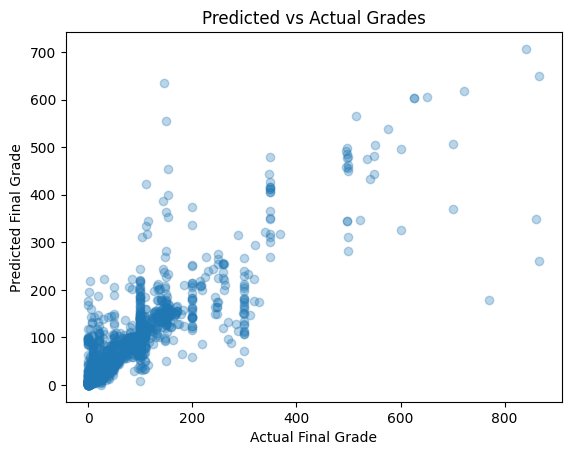

In [28]:
# Scatter plot to visualize prediction accuracy

plt.figure()

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")

plt.title("Predicted vs Actual Grades")

plt.show()